Initial imports

In [1]:
import pickle
import sys


import sys
from pathlib import Path

project_root = Path(".").resolve()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


import isop_co2Inhi_als.MultiVar as MultiVar
import isop_co2Inhi_als.MultiModel as MultiModel

from isop_co2Inhi_als.MultiVar import EMIISOP
from  isop_co2Inhi_als.plt import *

from isop_co2Inhi_als.visit_preprocess import VisitEMIISOP
import isop_co2Inhi_als.visit_preprocess as vp

import hcho_als.utils as utils
from hcho_als.utils import *
from hcho_als.plt import *


from isop_factor_als.visit_sensitivity_als import VisitSenAls
import isop_factor_als.visit_sensitivity_als as vsa
from isop_factor_als.plt import *

sys.modules["MultiModel"] = MultiModel

sys.modules["MultiVar"] = MultiVar
MultiVar.EMIISOP = EMIISOP

sys.modules["utils"] = utils
utils.HCHO = HCHO

sys.modules["visit_sensitivity_als"] = vsa
vsa.VisitSenAls = VisitSenAls

sys.modules["visit_preprocess"] = vp
vp.VisitEMIISOP = VisitEMIISOP


/home/ngoc/anaconda3/envs/bvoc/lib/python3.10/site-packages/regionmask/core/regions.py:9: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gp


In [2]:

emiisop_co2Inhi_2k = pickle.load(open("./plt_data/emiisop_co2Inhi_from2000s.pkl", "rb"))
emiisop_co2Inhi_1k9 = pickle.load(open("./plt_data/emiisop_co2Inhi_from1900s.pkl", "rb"))
emiisop_megan_compare = pickle.load(open("./plt_data/emiisop_megan_compare.pkl", "rb"))
interp_omi_v2 = pickle.load(open("./plt_data/interp_omi_v2.pkl", "rb"))
interp_tropo_v2 = pickle.load(open("./plt_data/interp_tropo_v2.pkl", "rb"))
visits = pickle.load(open("./plt_data/visits.pkl", "rb"))

Figure 1. Model simulations of isoprene emissions in response to atmospheric CO2 concentration (Cₐ) using two CO2 inhibition functions (dashed lines) compared with observations (solid lines) for five isoprene-emitting tree species. Data from Niinemets et al. (2021) and Possell and Hewitt (2011). Ismax, C*, and h are empirically determined coefficients. Also, Ca denotes the ambient CO2 concentration and Cast stands for the standard ambient CO2 concentration.

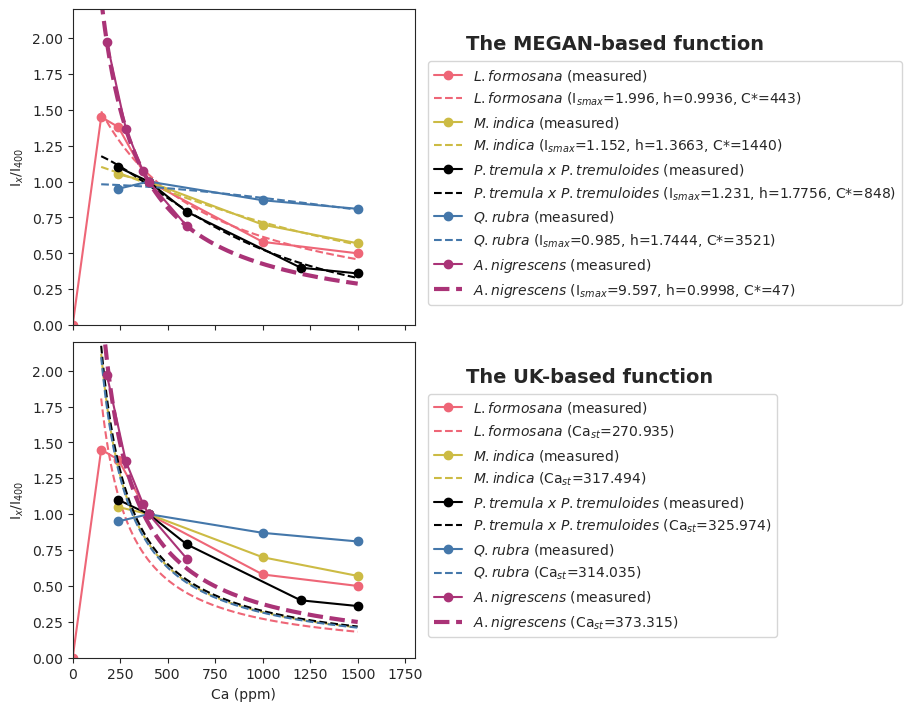

In [3]:
# %%
# Combined 2 subplots (share x) + right-side panel titles + italic species names in legend

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# -----------------------
# Models
# -----------------------
def wilkinson2009(Ca, Ismax, h, cstar):
    Ca = np.asarray(Ca, dtype=float)
    return Ismax * (1.0 - 1.0 / ((cstar / Ca) ** h + 1.0))


def ukesm(Ca, cast):
    Ca = np.asarray(Ca, dtype=float)
    return cast / Ca


# -----------------------
# Data
# -----------------------
species = [
    dict(
        key="L.formosana",
        color="#EE6677",
        marker="o",
        x_plot=[0, 150, 240, 400, 1000, 1500],
        y_plot=[0, 1.45, 1.38, 1.0, 0.58, 0.5],
        x_fit=[150, 240, 400, 1000, 1500],
        y_fit=[1.45, 1.38, 1.0, 0.58, 0.5],
    ),
    dict(
        key="M.indica",
        color="#CCBB44",
        marker="o",
        x_plot=[0, 240, 400, 1000, 1500],
        y_plot=[np.nan, 1.05, 1.0, 0.7, 0.57],
        x_fit=[240, 400, 1000, 1500],
        y_fit=[1.05, 1.0, 0.7, 0.57],
    ),
    dict(
        key="P.tremula x P.tremuloides",
        color="k",
        marker="o",
        x_plot=[0, 240, 400, 600, 1200, 1500],
        y_plot=[np.nan, 1.1, 1.0, 0.79, 0.4, 0.36],
        x_fit=[240, 400, 600, 1200, 1500],
        y_fit=[1.1, 1.0, 0.79, 0.4, 0.36],
    ),
    dict(
        key="Q.rubra",
        color="#4477AA",
        marker="o",
        x_plot=[0, 240, 400, 1000, 1500],
        y_plot=[np.nan, 0.95, 1.0, 0.87, 0.81],
        x_fit=[240, 400, 1000, 1500],
        y_fit=[0.95, 1.0, 0.87, 0.81],
    ),
    dict(
        key="A.nigrescens",
        color="#AA3377",
        marker="o",
        x_plot=[0, 180, 280, 370, 400, 600],
        y_plot=[np.nan, 1.970854, 1.367418, 1.071849, 1.0, 0.690692],
        x_fit=[180, 280, 370, 400, 600],
        y_fit=[1.970854, 1.367418, 1.071849, 1.0, 0.690692],
        lw_fit=3,
    ),
]


# -----------------------
# Helpers
# -----------------------
def _finite_xy(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    return x[m], y[m]


def italic_name(name: str) -> str:
    # Mathtext italics; keep spaces visible in mathtext
    return r"$\it{" + name.replace(" ", r"\ ") + "}$"


def plot_panel(ax, model_name, model_func, p0, bounds, legend_fmt):
    # Smooth curve range (avoid Ca=0)
    x_grid = np.linspace(150, 1500, 400)

    for sp in species:
        # measured
        x_m, y_m = _finite_xy(sp["x_plot"], sp["y_plot"])
        ax.plot(
            x_m,
            y_m,
            color=sp["color"],
            marker=sp.get("marker", "o"),
            linestyle="-",
            label=f"{italic_name(sp['key'])} (measured)",
        )

        # fit
        x_f, y_f = _finite_xy(sp["x_fit"], sp["y_fit"])
        popt, _ = curve_fit(
            model_func,
            x_f,
            y_f,
            p0=p0,
            bounds=bounds,
            maxfev=20000,
        )

        # fitted curve (smooth)
        y_grid = model_func(x_grid, *popt)

        ax.plot(
            x_grid,
            y_grid,
            color=sp["color"],
            linestyle="--",
            linewidth=sp.get("lw_fit", 1.5),
            label=legend_fmt(sp["key"], popt),
        )

    ax.set_ylim(0, 2.2)
    ax.set_xlim(0, 1800)
    ax.set_ylabel("I$_x$/I$_{400}$")

    # title on the right of the panel
    ax.text(
        1.15,
        0.92,
        model_name,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
    )

    # legend on the right
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.45))


# -----------------------
# Build combined figure (2 panels share x)
# -----------------------
fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True,
    constrained_layout=True,
)

# Top panel: MEGAN-based (Wilkinson 2009)
plot_panel(
    axes[0],
    model_name="The MEGAN-based function",
    model_func=wilkinson2009,
    p0=(1.0, 1.0, 400.0),
    bounds=([0.0, 0.0, 1.0], [np.inf, np.inf, np.inf]),
    legend_fmt=lambda n, p: (
        f"{italic_name(n)} " f"(I$_{{smax}}$={p[0]:.3f}, h={p[1]:.4f}, C*={p[2]:.0f})"
    ),
)

# Bottom panel: UK-based
plot_panel(
    axes[1],
    model_name="The UK-based function",
    model_func=ukesm,
    p0=(400.0,),
    bounds=([1.0], [np.inf]),
    legend_fmt=lambda n, p: f"{italic_name(n)} (Ca$_{{st}}$={p[0]:.3f})",
)

# shared x label only on bottom
axes[1].set_xlabel("Ca (ppm)")
axes[0].set_xlabel("")

plt.show()
# %%


Figure 2. Spatial distribution of mean annual isoprene emissions (in gC m–2 yr–1) in the present day (2000–2023) from the VISIT simulation without CO2 inhibition (VISIT-woCO2inhi) and emission differences among sensitivity cases (e.g., VISIT-wCO2inhi-MEGANpft) and VISIT-woCO2inhi.

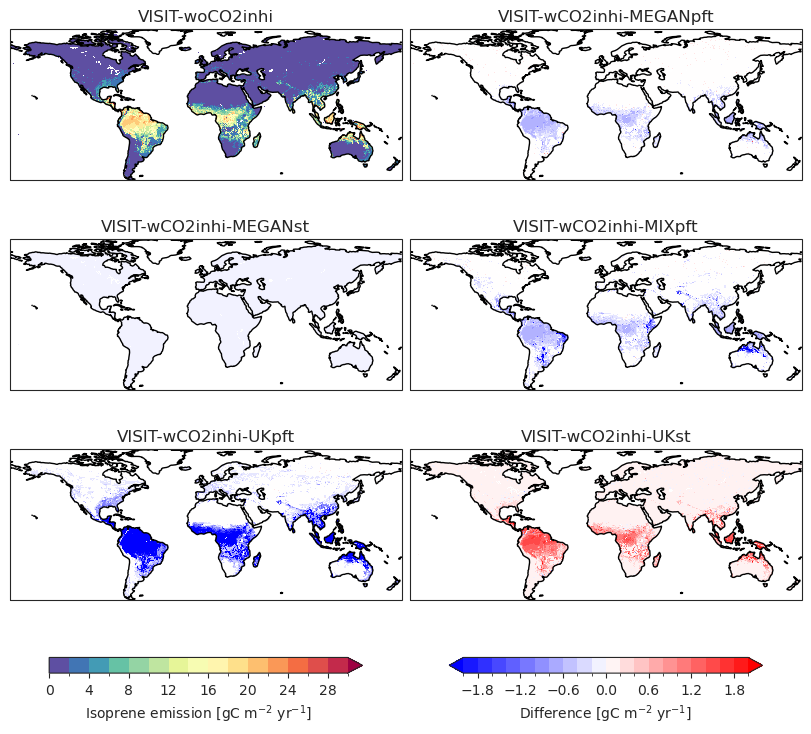

In [4]:
plt_glob_present_diff_map(emiisop_co2Inhi_2k)

Figure 3. Interannual variation of isoprene emissions globally (a) and in selected regions (b) as defined in (c) for 2000–2023 from VISIT sensitivity simulations: AMZ, Amazonia; ENA, Eastern North America; N_Africa, Northern Africa; C_Africa, Central Africa; S_Africa, Southern Africa; NAU, Northern Australia.

VISIT-wCO2inhi-MEGANpft Mann_Kendall_Test(trend='increasing', h=True, p=2.8287791442593857e-07, z=5.13451142244029, Tau=0.7536231884057971, s=208.0, var_s=1625.3333333333333, slope=1.3222972327519351, intercept=488.08717535589363)
VISIT-wCO2inhi-MEGANst Mann_Kendall_Test(trend='increasing', h=True, p=2.2197854009586848e-05, z=4.241552914189805, Tau=0.6231884057971014, s=172.0, var_s=1625.3333333333333, slope=1.1513669499521564, intercept=506.829378523677)
VISIT-wCO2inhi-MIXpft Mann_Kendall_Test(trend='increasing', h=True, p=7.970997484285647e-07, z=4.936076198384627, Tau=0.7246376811594203, s=200.0, var_s=1625.3333333333333, slope=1.0727834237623055, intercept=480.0049436285869)
VISIT-wCO2inhi-UKpft Mann_Kendall_Test(trend='decreasing', h=True, p=1.7958432074749453e-08, z=-5.6305994825794485, Tau=-0.8260869565217391, s=-228.0, var_s=1625.3333333333333, slope=-1.4070717402539583, intercept=429.42197143099287)
VISIT-wCO2inhi-UKst Mann_Kendall_Test(trend='decreasing', h=True, p=1.79584320

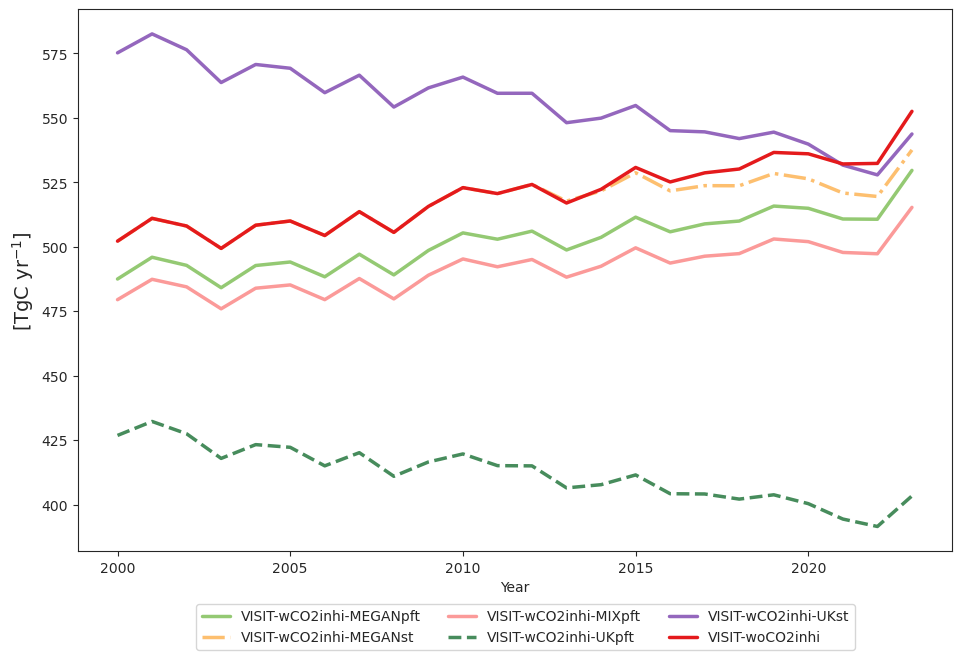

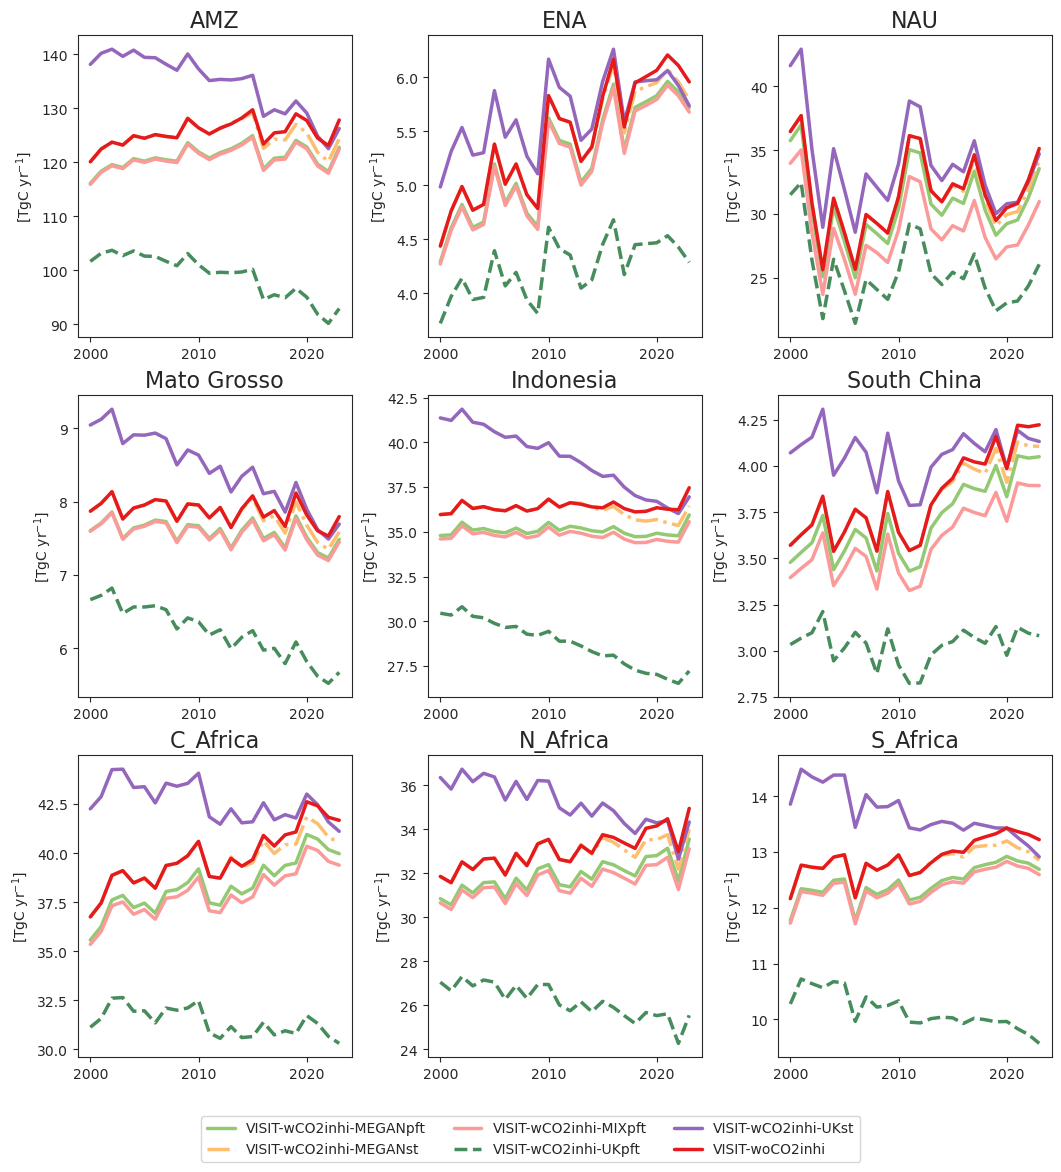

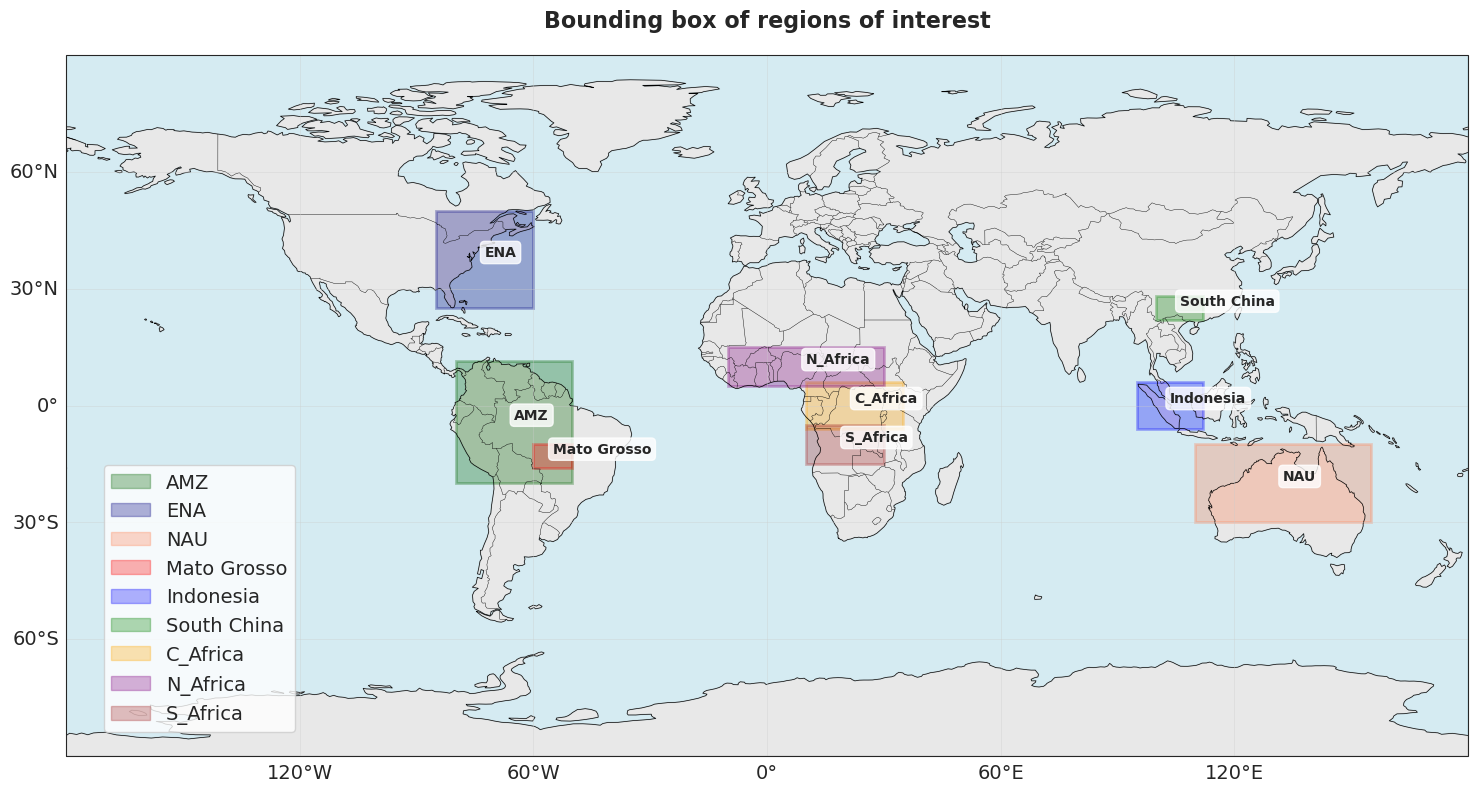

In [5]:
plt_glob_annual_variation(emiisop_co2Inhi_2k) # Figure 3a
plt_reg_annual_variation(emiisop_co2Inhi_2k) # Figure 3b
plt_regional_bbox() # Figure 3c

Figure 4. Global distribution of annual isoprene emission trends for 2000–2023. The first panel shows the relative trend (% yr-¹) from the VISIT simulation without CO2 inhibition (VISIT-woCO2inhi), including only significant values (with p < 0.05). Subsequent panels present relative trend differences (% yr-¹) for each CO2 inhibition sensitivity case (e.g. VISIT-wCO2inhi-MEGANpft minus VISIT-woCO2inhi).

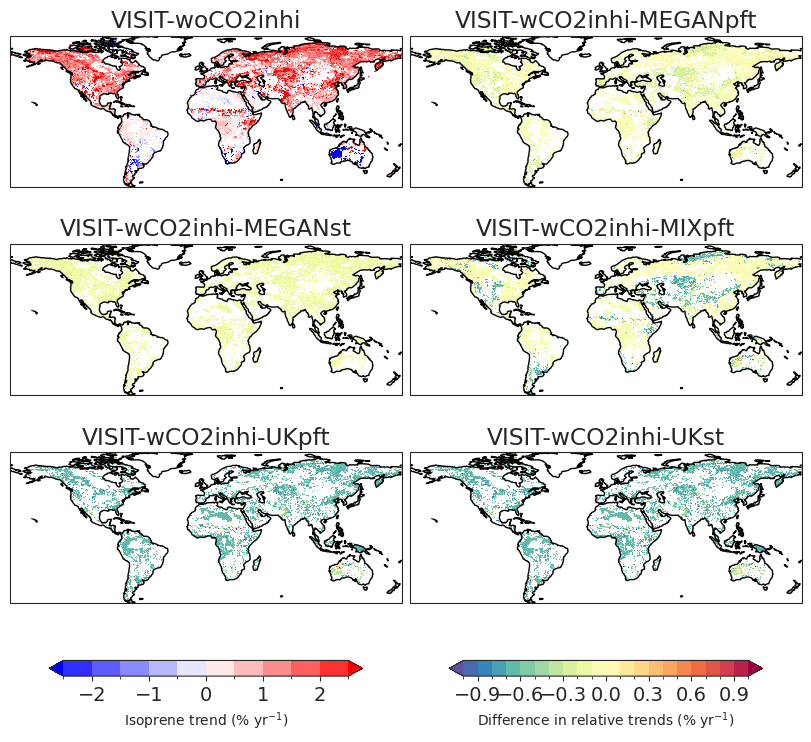

In [6]:
plt_emiisop_trends_diff_map(emiisop_co2Inhi_2k)

Figure 5. (a) Time series of isoprene emission changes (TgC yr⁻¹) relative to the year 2000 for MEGANpft, UKpft, and woCO2inhi simulations, attributed to CO2 fertilization (co2f), CO2 inhibition (co2fi), land-use and land-cover change (lulcc), climate (clim), and all combined factors (all). (b) Attributed linear trends in global isoprene emissions for each driver; asterisks (*) denote p < 0.05.

1.575723800249008
-0.5990400560672408
0.6833271384144362
-1.4656152388517936
-0.49465091759842206
-2.141277122442068
1.96598170418891
-0.6190057291633527
1.0074955601123419


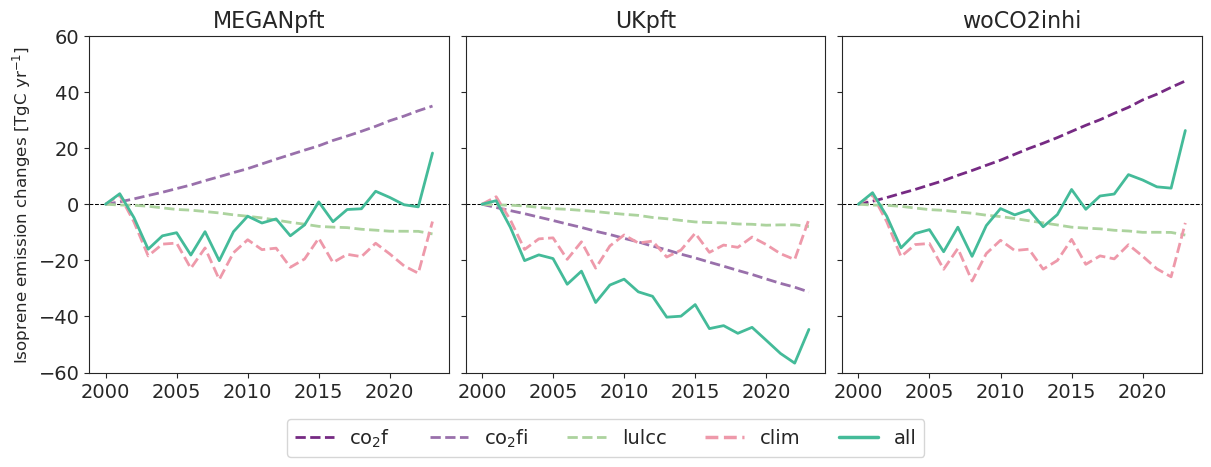

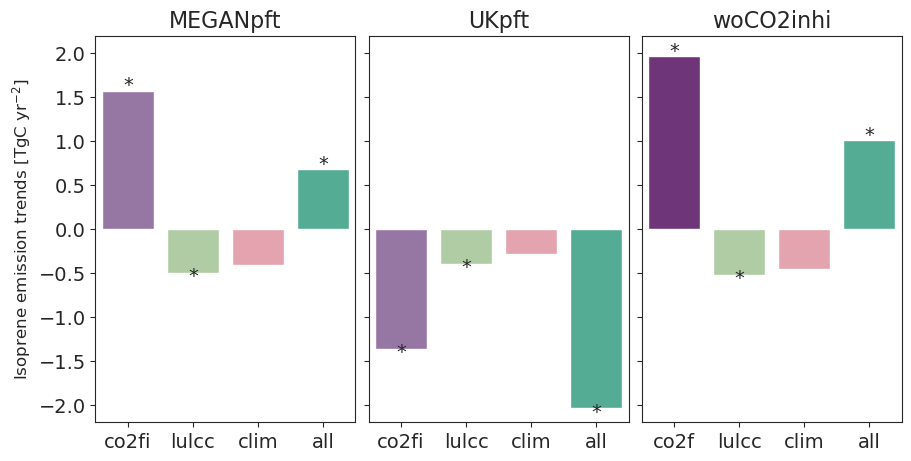

In [7]:
plt_glob_changes_by_driver(visits, "main") # Figure 5a
plt_glob_trends_by_driver(visits, "main") # Figure 5b

Figure 6. (a) Time series of isoprene emission changes (TgC yr⁻¹) relative to the year 2000 for MEGANpft, UKpft, and woCO2inhi simulations, attributed to temperature (tas), shortwave radiation (rsds), precipitation (pr), and total climate factors (clim). (b) Attributed linear trends in global isoprene emissions for each climate driver; asterisks (*) denote p < 0.05.

0.543026114131549
-0.3538099870507183
-0.61340655539864
0.40843049450036306
-0.31043827929481177
-0.40360356508718664
0.5673172679364349
-0.36381122766054674
-0.6658723061925892


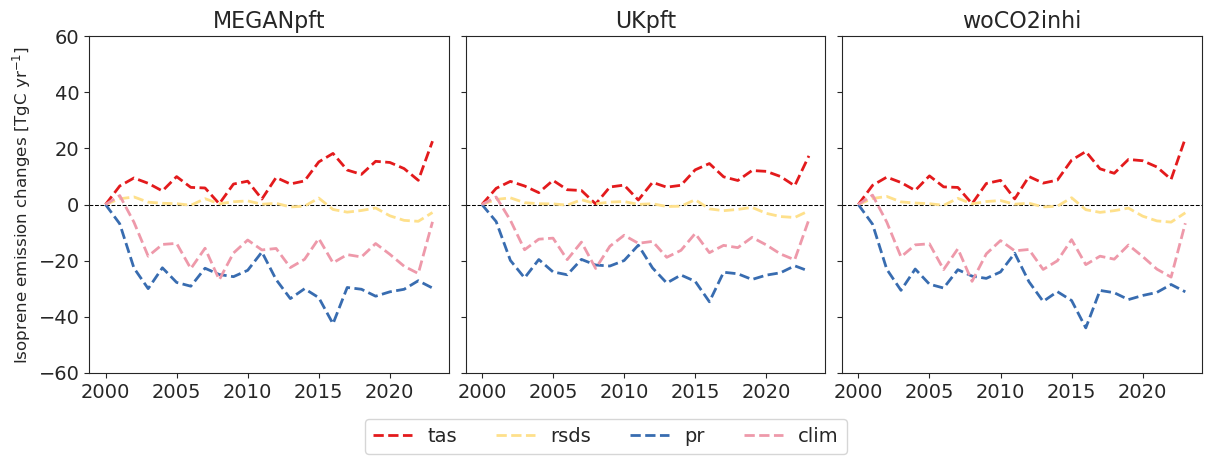

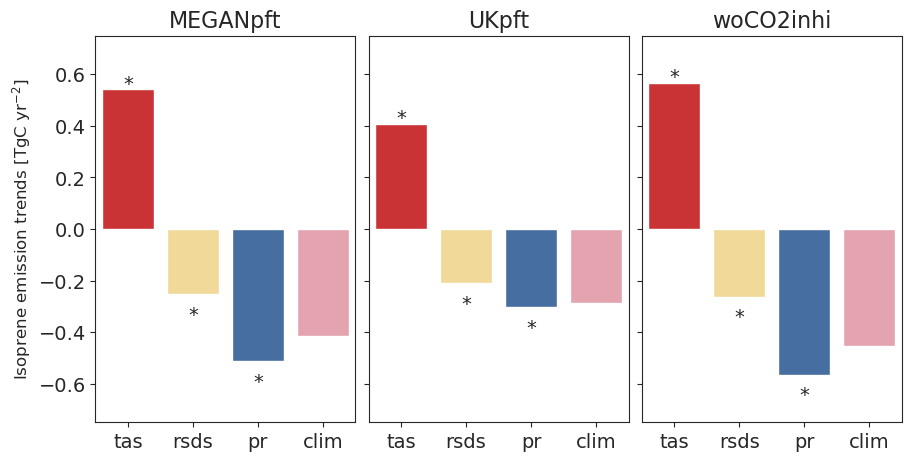

In [8]:
plt_glob_changes_by_driver(visits, "clim") # Figure 6a
plt_glob_trends_by_driver(visits, "clim") # Figure 6b

Figure 7. Global (a) and regional (b) annual isoprene emission totals from selected VISIT sensitivity simulations and other available datasets. Numbers in panel (a) show global emission trends during the study period. Time periods differ among datasets.

ALBERI-v2021 Mann_Kendall_Test(trend='no trend', h=False, p=0.0814429797390801, z=1.7423742438807115, Tau=0.30718954248366015, s=47.0, var_s=697.0, slope=1.0671059154981404, intercept=297.13217258169556)
CAMS-GLOB-BIO Mann_Kendall_Test(trend='increasing', h=True, p=0.005899983624599869, z=2.7532887337723295, Tau=0.4057971014492754, s=112.0, var_s=1625.3333333333333, slope=1.2838659434705906, intercept=372.1605523566973)
OMIv2-TOPDOWN Mann_Kendall_Test(trend='no trend', h=False, p=0.854777098065548, z=0.1830266628259689, Tau=0.05128205128205128, s=4.0, var_s=268.6666666666667, slope=0.4517940231432078, intercept=389.0773756647963)
VISIT-wCO2inhi-MEGANpft Mann_Kendall_Test(trend='increasing', h=True, p=2.8287791442593857e-07, z=5.13451142244029, Tau=0.7536231884057971, s=208.0, var_s=1625.3333333333333, slope=1.3222972327519351, intercept=488.08717535589363)
VISIT-wCO2inhi-UKpft Mann_Kendall_Test(trend='decreasing', h=True, p=1.7958432074749453e-08, z=-5.6305994825794485, Tau=-0.82608695

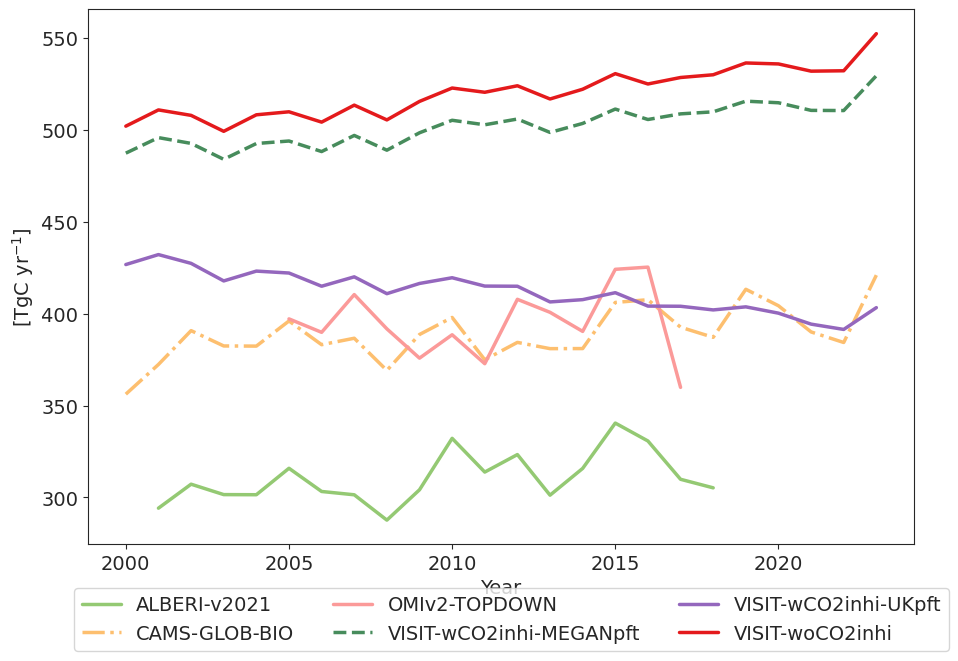

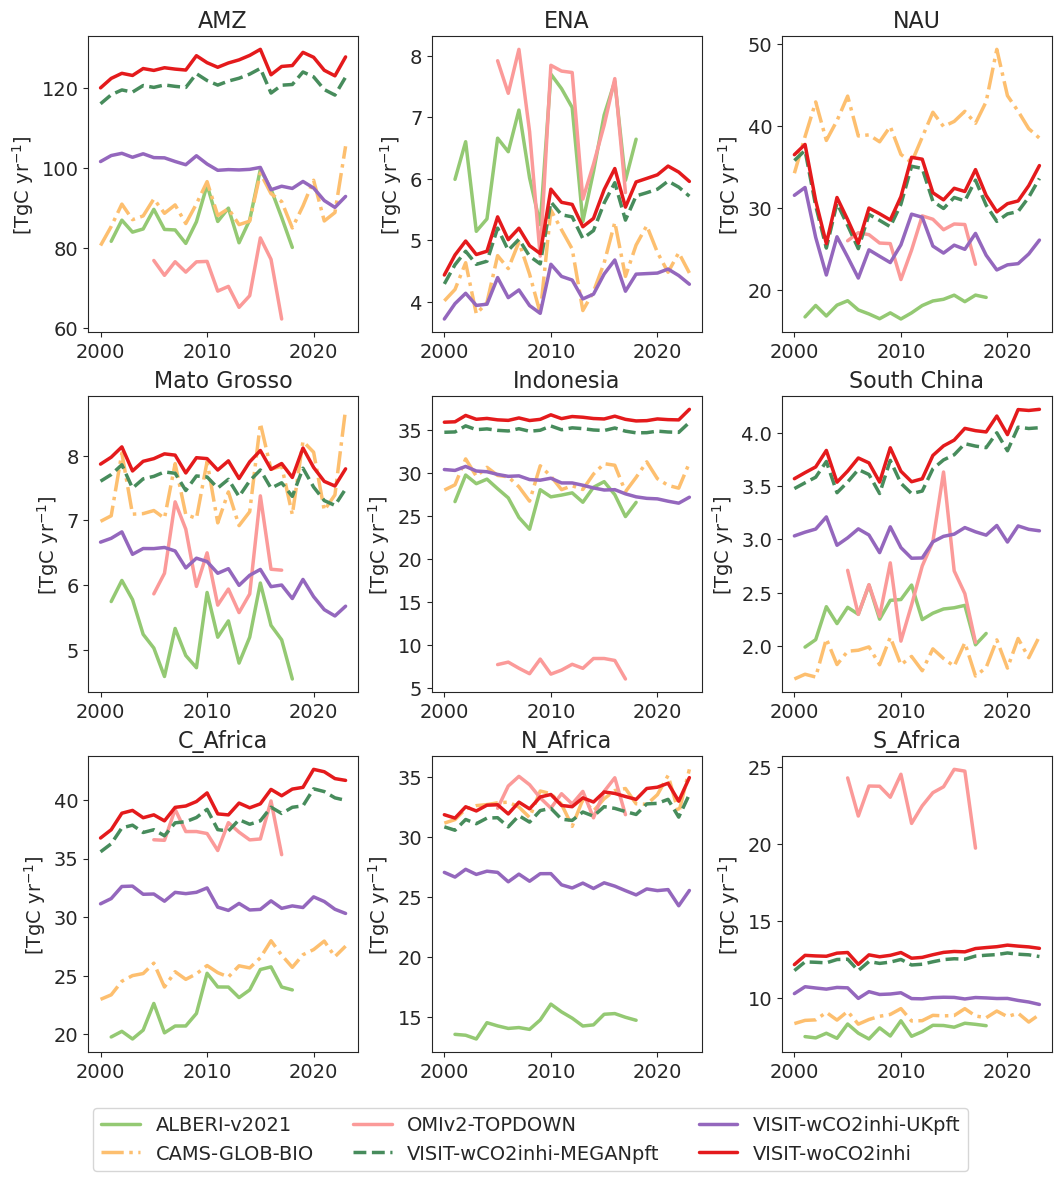

In [9]:
plt_glob_annual_variation(emiisop_megan_compare)
plt_reg_annual_variation(emiisop_megan_compare)

Figure 8. Mean annual total column HCHO from all emissions (a) and from the BVOC contribution (b) in CHASER, compared with OMI HCHO observations (2005–2022) over nine selected regions. The BVOC contribution to HCHO simulations is estimated by subtracting simulations without BVOC emissions from those that include anthropogenic, biomass burning, and each isoprene sensitivity case.

Figure 9. Decadal HCHO trends (% per decade) of 2005–2022.

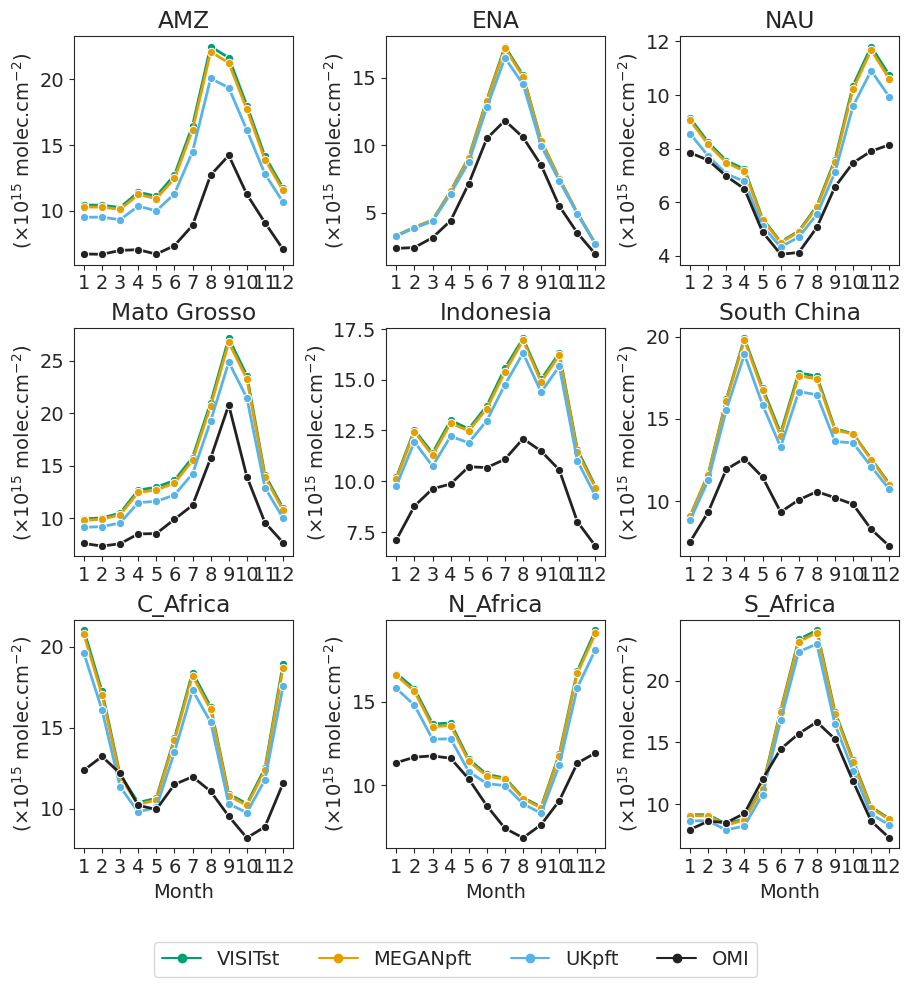

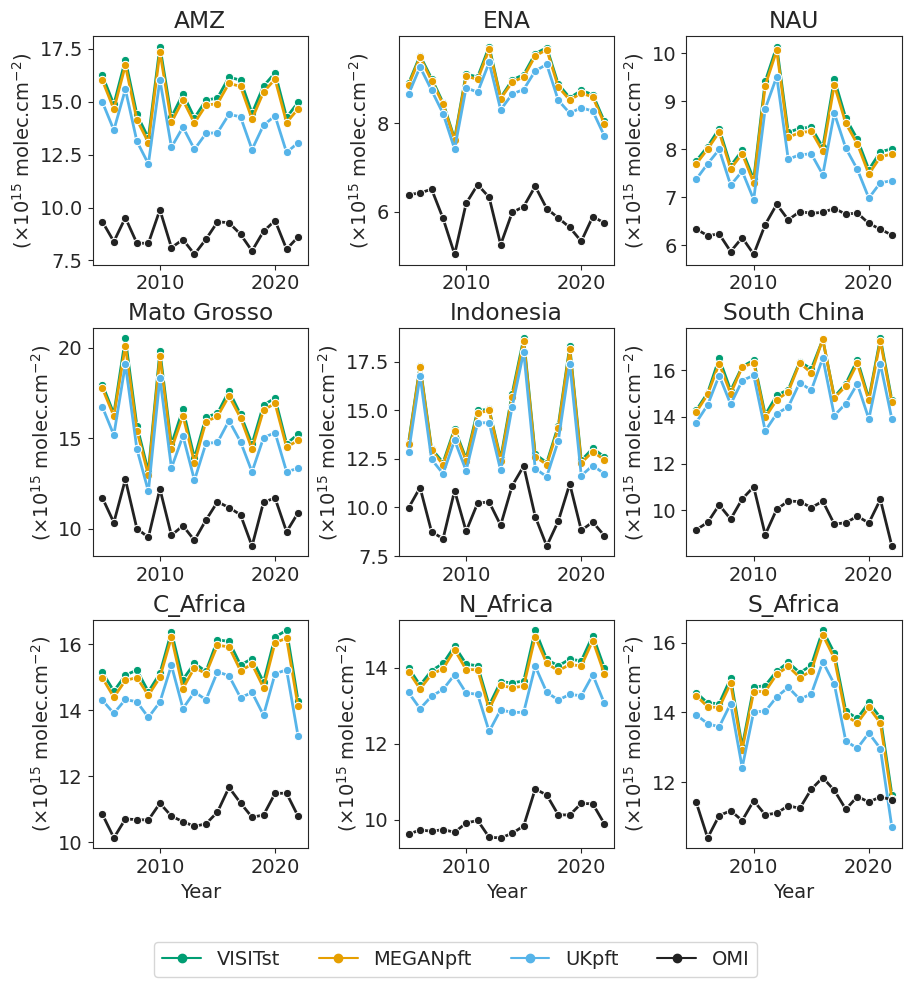

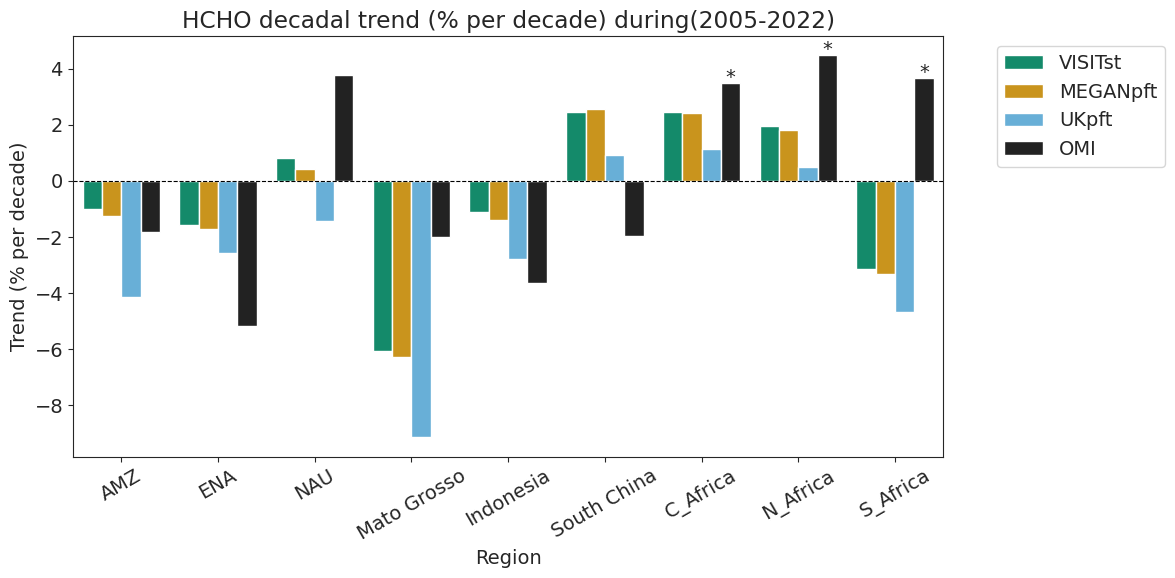

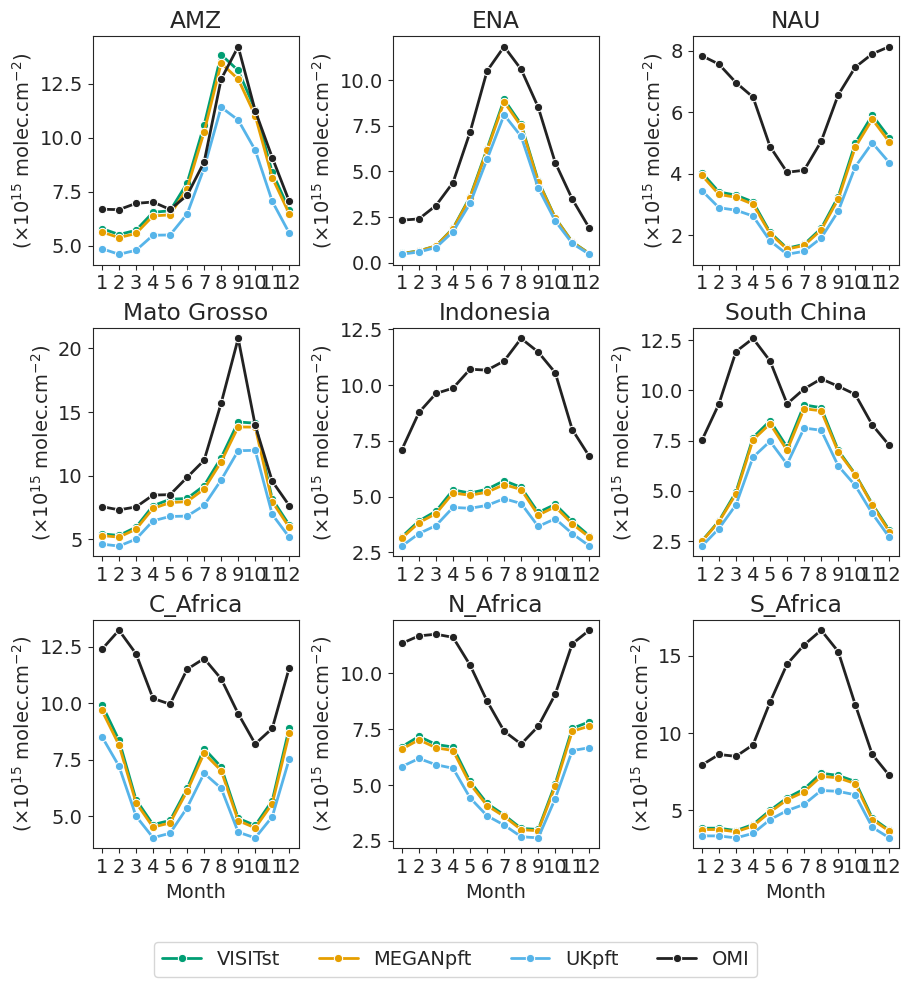

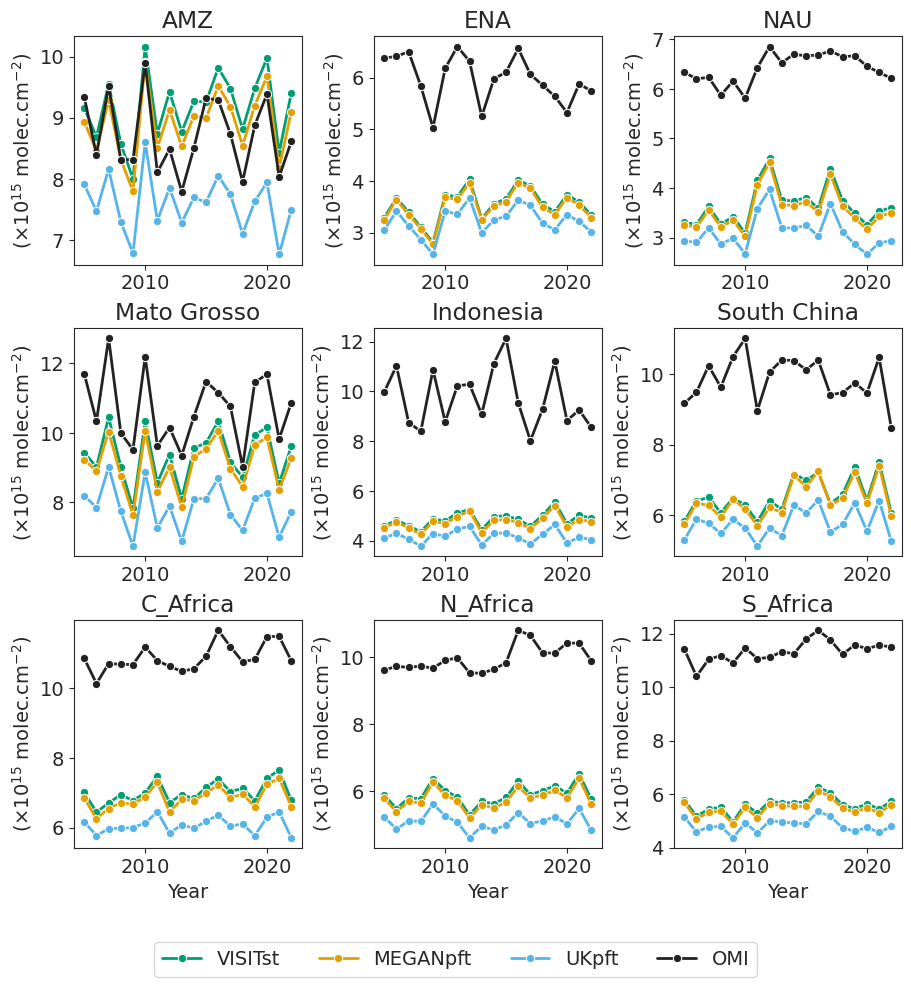

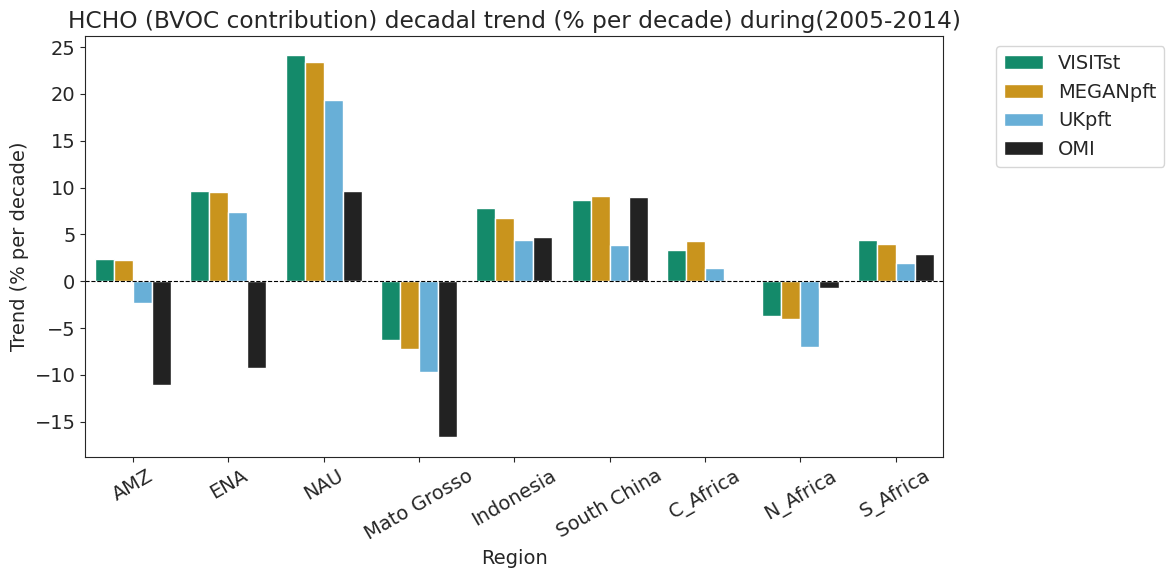

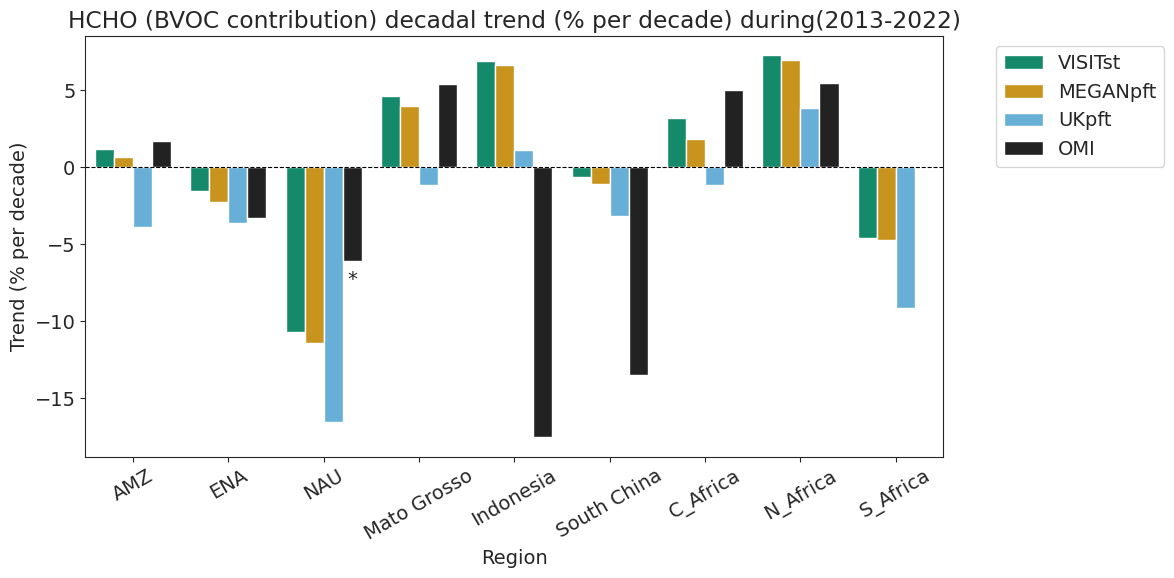

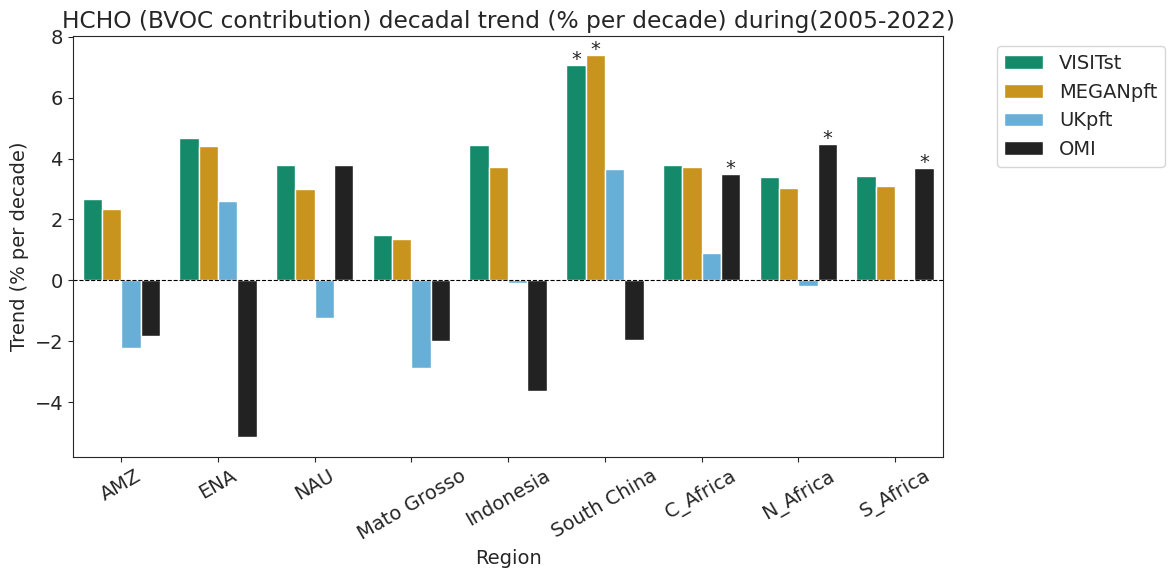

,Region,Model,Decadal trend (% per decade),Significant,Period
0,AMZ,VISITst,2.412531,0,2005-2014
1,AMZ,VISITst,1.166588,0,2013-2022
2,AMZ,VISITst,2.675857,0,2005-2022
3,AMZ,MEGANpft,2.242689,0,2005-2014
4,AMZ,MEGANpft,0.677239,0,2013-2022
...,...,...,...,...,...
103,S_Africa,UKpft,-9.125229,0,2013-2022
104,S_Africa,UKpft,0.047881,0,2005-2022
105,S_Africa,OMI,2.933119,0,2005-2014
106,S_Africa,OMI,-0.072629,0,2013-2022


In [10]:
plt_reg(interp_omi_v2, norm=False, unit=None, sslat=False)
plt_reg_bvoc_contri(interp_omi_v2, norm=False, unit=None, sslat=False)

Figure 10. Global distribution of decadal HCHO trends (% per decade) for 2005–2022. The top row shows observed trends (OMI) and the baseline VISITst simulation without CO2 inhibition effects. The middle row shows simulated trends using MEGANpft and UKpft CO2-inhibition functions, with colors representing deviations from the VISITst trends. The bottom row highlights regions in which MEGANpft and UKpft improve or worsen the agreement with OMI relative to VISITst.

[ 1.  2. nan]
[ 1.  2. nan]


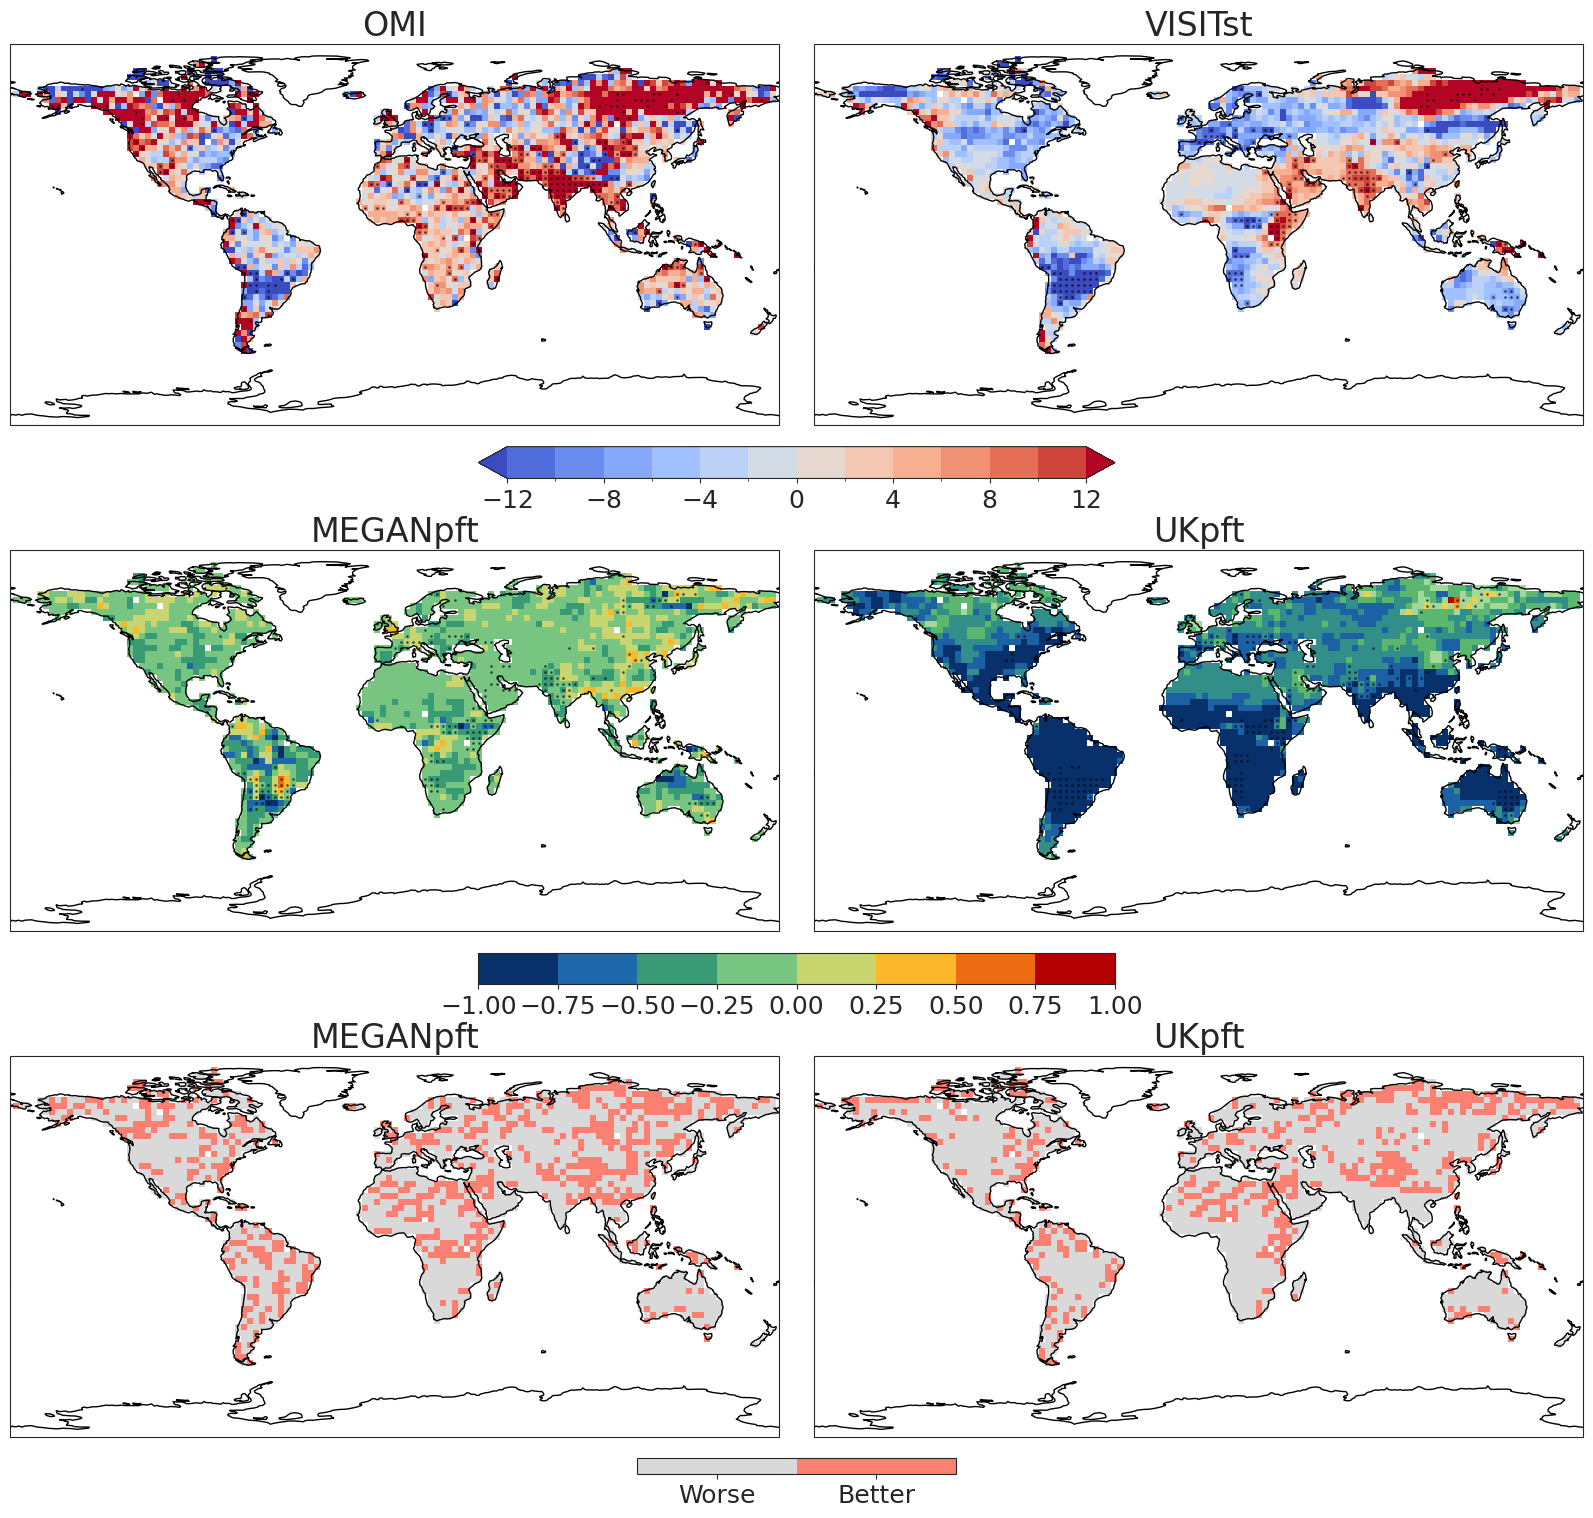

In [11]:
plt_trend(method="linear")

Figure 11. Time series of global annual isoprene emissions (TgC yr⁻¹) during 1901–2023 simulated by VISIT under different isoprene emission schemes, including simulations with CO2 inhibition (VISIT-wCO2inhi-MEGANst, -UKst, -MIXpft, -MEGANpft, and -UKpft) and without CO2 inhibition (VISIT-woCO2inhi, solid red line).

VISIT-wCO2inhi-MEGANpft Mann_Kendall_Test(trend='increasing', h=True, p=0.0, z=12.50877481134138, Tau=0.76276156204185, s=5723.0, var_s=209250.33333333334, slope=0.6594878889070874, intercept=394.01271740599844)
VISIT-wCO2inhi-MEGANst Mann_Kendall_Test(trend='increasing', h=True, p=0.0, z=12.862920480589425, Tau=0.7843529254964681, s=5885.0, var_s=209250.33333333334, slope=0.727758496298775, intercept=397.69302729065623)
VISIT-wCO2inhi-MIXpft Mann_Kendall_Test(trend='increasing', h=True, p=0.0, z=11.717412266478469, Tau=0.7145141943222711, s=5361.0, var_s=209250.33333333334, slope=0.5466166459209352, intercept=401.57023183467584)
VISIT-wCO2inhi-UKpft Mann_Kendall_Test(trend='decreasing', h=True, p=0.0, z=-13.588700494110105, Tau=-0.8286018925763028, s=-6217.0, var_s=209250.33333333334, slope=-0.522148287739396, intercept=472.1979384050617)
VISIT-wCO2inhi-UKst Mann_Kendall_Test(trend='decreasing', h=True, p=0.0, z=-13.61056133789085, Tau=-0.8299346927895509, s=-6227.0, var_s=209250.3333

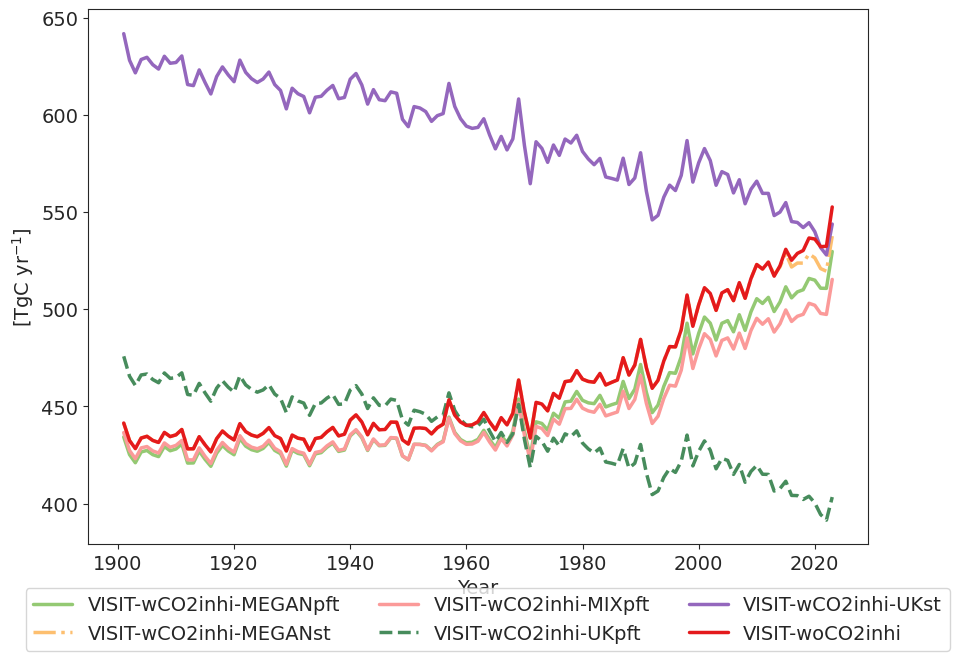

In [12]:
plt_glob_annual_variation(emiisop_co2Inhi_1k9)